<a href="https://colab.research.google.com/github/adljna/Blu-SentimentAnalysis/blob/main/Week%204/TF-IDF/1C-TFIDF-DetikNews.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **(1) Import Dependencies**
This section initializes all necessary Python libraries for text processing, TF-IDF calculation, and visualization.

In [6]:
import nltk
from nltk.tokenize import sent_tokenize
from nltk.corpus import stopwords
nltk.download('punkt')
nltk.download('stopwords')
from sklearn.feature_extraction.text import TfidfVectorizer
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


# **(2) Define Document**
This section defines the input document (news article) that will be processed for TF-IDF based summarization.

In [3]:
manchester = """Manchester City makes history by winning Club World Cup
Manchester City capped off its incredible year with yet another trophy, dismantling Fluminense 4-0 to win the Club World Cup on Friday.
Having already won the Premier League, Champions League, FA Cup and Super Cup, Pep Guardiola’s side now boasts five trophies this calendar year, becoming the first English club to ever hold all those titles simultaneously.
The final piece of the jigsaw came on a highly charged night in Saudi Arabia as Manchester City outclassed its Brazilian opponents.

“We’ve shown over the past 12 months we are the best team in the world. Our results prove that and the consistency we have managed has been amazing,” club captain Kyle Walker said after the game, per Sky Sports.
“To win these five trophies – for me, the five biggest prizes available to us – is incredible. I am so proud to have been a part of this and I can honestly say it’s an honour to play alongside these players. I couldn’t ask for better teammates.”

It took just 40 seconds for Manchester City to take the lead.
Brazilian left-back Marcelo miscued a pass in the opening exchanges which let Nathan Aké free to shoot from distance. The defender’s effort cannoned back off the post but forward Julián Álvarez was in the right place to turn the rebound into the net with his chest.
City continued to look dangerous and doubled its lead before the break after Phil Foden’s attempted cross was deflected into his own net by Fluminense defender Nino.

Foden then got on the scoresheet himself in the 72nd minute after a prodding home from close range.

The rout was completed in the 88th minute when Álvarez capped off a brilliant performance with a clinical finish into the far corner.

City’s defence was largely untested for during the game, underlining the team’s dominance during this unforgettable year.

“As a manager it is what I am most proud of; that we are always there. No matter how much we win, no matter what trophies we lift, we are there again to fight for the next one,” City boss Guardiola said after the match, according to Sky Sports.

“To win the Treble was truly special, but to win two more trophies and now hold these five major titles shows the unique mentality of this team, of the Club and its fans.

“It is something no other English team has ever achieved, and we will always remember this incredible time we spent together.”

The game ended in some unsavoury scenes as a scuffle broke out between players on the pitch after the final whistle, but the game will be remembered as yet another successful night for City.

The champion heads back to England where it faces a tough title defence in the Premier League.

It currently sits fourth in the table and will face Everton in its next fixture on Wednesday."""

# **(3) Text Preprocessing**
This section covers the initial steps to clean and prepare the text, making it suitable for TF-IDF analysis. It involves breaking the text into sentences and removing common, less informative words.

### Sentence Tokenization

This step breaks down the large block of text into individual sentences. This is crucial for summarization, as TF-IDF scores will be calculated per sentence, and sentences with higher scores will be selected for the summary.

In [7]:
# Sentence tokenization
sentence = sent_tokenize(manchester)
print("Tokenized sentences:")
for sent in sentence:
    print(sent)

Tokenized sentences:
Manchester City makes history by winning Club World Cup
Manchester City capped off its incredible year with yet another trophy, dismantling Fluminense 4-0 to win the Club World Cup on Friday.
Having already won the Premier League, Champions League, FA Cup and Super Cup, Pep Guardiola’s side now boasts five trophies this calendar year, becoming the first English club to ever hold all those titles simultaneously.
The final piece of the jigsaw came on a highly charged night in Saudi Arabia as Manchester City outclassed its Brazilian opponents.
“We’ve shown over the past 12 months we are the best team in the world.
Our results prove that and the consistency we have managed has been amazing,” club captain Kyle Walker said after the game, per Sky Sports.
“To win these five trophies – for me, the five biggest prizes available to us – is incredible.
I am so proud to have been a part of this and I can honestly say it’s an honour to play alongside these players.
I couldn’t a

### Stop Word Removal

Stop words are common words (like 'yang', 'dan', 'ini' in Indonesian) that don't carry much meaning and can skew TF-IDF scores. This step removes them to focus on more significant terms.

In [22]:
import re
# Get English stop words
english_stop_words = set(stopwords.words('english'))

cleaned_sentences = []
for sent in sentence:
    words = sent.lower().split() # Convert to lowercase and split into words
    filtered_words = []
    for word in words:
        cleaned_word = re.sub(r'[^a-z]', '', word) # Keep only alphabetic characters
        if cleaned_word and cleaned_word not in english_stop_words:
            filtered_words.append(cleaned_word)
    cleaned_sentences.append(" ".join(filtered_words))

print("\nCleaned sentences (English stop words removed, punctuation handled):")
for clean_sent in cleaned_sentences:
    print(clean_sent)


Cleaned sentences (English stop words removed, punctuation handled):
manchester city makes history winning club world cup manchester city capped incredible year yet another trophy dismantling fluminense win club world cup friday
already premier league champions league fa cup super cup pep guardiolas side boasts five trophies calendar year becoming first english club ever hold titles simultaneously
final piece jigsaw came highly charged night saudi arabia manchester city outclassed brazilian opponents
weve shown past months best team world
results prove consistency managed amazing club captain kyle walker said game per sky sports
win five trophies five biggest prizes available us incredible
proud part honestly say honour play alongside players
couldnt ask better teammates took seconds manchester city take lead
brazilian leftback marcelo miscued pass opening exchanges let nathan ak free shoot distance
defenders effort cannoned back post forward julin lvarez right place turn rebound net 

# **(4) Scikit-learn TF-IDF Vectorization**

This section uses the `TfidfVectorizer` from scikit-learn to efficiently compute the TF-IDF scores for all words across all cleaned sentences. This vectorized representation is then used for the summarization process.

In [23]:
# Training TF-IDF Vectorizer on the cleaned sentences
vectorizer = TfidfVectorizer()
features = vectorizer.fit_transform(cleaned_sentences)
feature_names = vectorizer.get_feature_names_out()

In [24]:
print("\nTF-IDF Feature Matrix (Sparse) on Cleaned Sentences:")
print(features)
print("\nShape of the Feature Matrix (Number of sentences, Number of unique words):")
print(features.shape)

# To see the feature names (the words in the vocabulary after Indonesian stop word removal):
feature_names = vectorizer.get_feature_names_out()
print("\nFeature Names (Words in the vocabulary):")
print(feature_names)


TF-IDF Feature Matrix (Sparse) on Cleaned Sentences:
<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 257 stored elements and shape (20, 203)>
  Coords	Values
  (0, 106)	0.3289588507448436
  (0, 32)	0.25970573883989273
  (0, 103)	0.2073683147647439
  (0, 85)	0.2073683147647439
  (0, 199)	0.2073683147647439
  (0, 36)	0.30134457383703345
  (0, 200)	0.3645598455453162
  (0, 43)	0.3645598455453162
  (0, 26)	0.1822799227726581
  (0, 90)	0.1644794253724218
  (0, 201)	0.1644794253724218
  (0, 202)	0.1822799227726581
  (0, 7)	0.1822799227726581
  (0, 184)	0.2073683147647439
  (0, 50)	0.2073683147647439
  (0, 72)	0.1822799227726581
  (0, 198)	0.15067228691851672
  (0, 78)	0.2073683147647439
  (1, 36)	0.147218687822625
  (1, 43)	0.35620367349322135
  (1, 201)	0.16070934922652655
  (1, 4)	0.20261517111082558
  (1, 138)	0.17810183674661068
  (1, 96)	0.35620367349322135
  (1, 29)	0.20261517111082558
  :	:
  (17, 155)	0.1986214844264415
  (17, 22)	0.1986214844264415
  (17, 133)	0.19862

# **(5) TF-IDF Based Summarization**

This section calculates the average TF-IDF score for each sentence and identifies sentences that are most representative of the document based on a calculated threshold. These sentences then form the summary.

In [25]:
# To see the TF-IDF values for a specific cleaned sentence (e.g., the first):
if cleaned_sentences:
    first_cleaned_sentence_tfidf = features[0].toarray()
    print("\nTF-IDF values for the first sentence:")
    print(first_cleaned_sentence_tfidf)

    def get_tfidf_for_sentence(tfidf_matrix, sentence_index, feature_names):
        """Returns a DataFrame of TF-IDF values for a given sentence."""
        sentence_tfidf_values = tfidf_matrix[sentence_index].toarray().flatten()
        tfidf_df = pd.DataFrame({'Feature': feature_names, 'TF-IDF': sentence_tfidf_values})
        tfidf_df = tfidf_df[tfidf_df['TF-IDF'] > 0].sort_values(by='TF-IDF', ascending=False)
        return tfidf_df

    first_cleaned_sentence_tfidf_df = get_tfidf_for_sentence(features, 0, feature_names)
    print("\nTF-IDF values for the first cleaned sentence (sorted):")
    print(first_cleaned_sentence_tfidf_df)
else:
    print("\nNo cleaned sentences to process.")


TF-IDF values for the first sentence:
[[0.         0.         0.         0.         0.         0.
  0.         0.18227992 0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.18227992 0.         0.         0.
  0.         0.         0.25970574 0.         0.         0.
  0.30134457 0.         0.         0.         0.         0.
  0.         0.36455985 0.         0.         0.         0.
  0.         0.         0.20736831 0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.18227992 0.         0.         0.         0.         0.
  0.20736831 0.         0.         0.         0.         0.
  0.         0.20736831 0.         0.         0.         0.
  0.16447943 0.         0.         0.         0.         0.
 

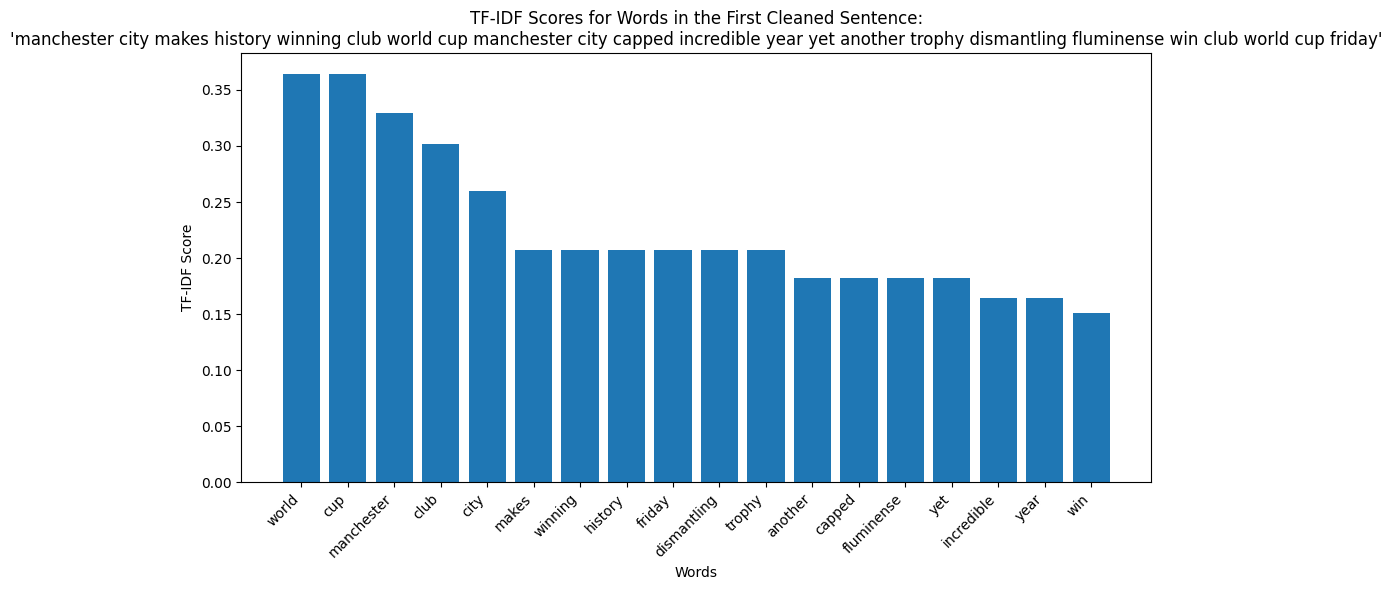

In [26]:
# Get TF-IDF scores for the first sentence
if cleaned_sentences:
    first_cleaned_sentence = cleaned_sentences[0]
    first_sentence_tfidf_df = get_tfidf_for_sentence(features, 0, feature_names)

    # Visualize the TF-IDF scores as a histogram
    plt.figure(figsize=(10, 6))
    plt.bar(first_sentence_tfidf_df['Feature'], first_sentence_tfidf_df['TF-IDF'])
    plt.xlabel("Words")
    plt.ylabel("TF-IDF Score")
    plt.title(f"TF-IDF Scores for Words in the First Cleaned Sentence:\n'{first_cleaned_sentence}'")
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print("No cleaned sentences to visualize.")

### TF-IDF Score for 'world' in Each Sentence


TF-IDF Scores for 'world' in each sentence::


,Sentence Number,TF-IDF Score (world)
0,1,0.364560
1,2,0.000000
2,3,0.000000
3,4,0.347413
4,5,0.000000
5,6,0.000000
6,7,0.000000
7,8,0.000000
8,9,0.000000
9,10,0.000000


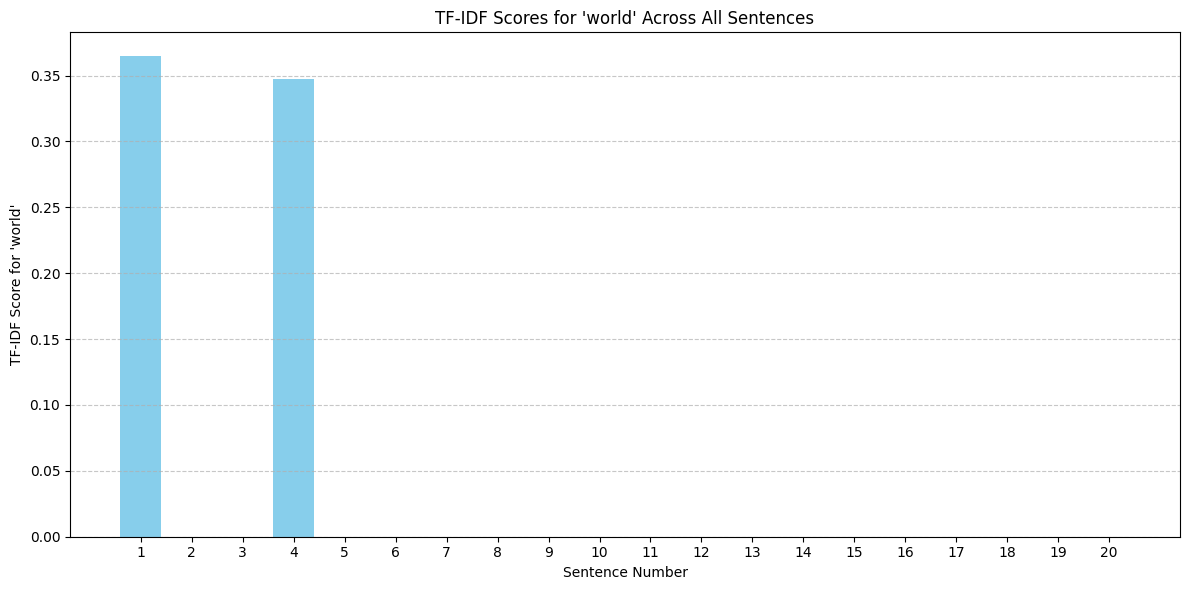

In [29]:
world_index = list(feature_names).index('world')
world_tfidf_scores = []
for i, _ in enumerate(sentence):
    score = features[i, world_index] # Get TF-IDF score for 'world' in sentence i
    world_tfidf_scores.append(score)

world_df = pd.DataFrame({
    'Sentence Number': range(1, len(sentence) + 1),
    'TF-IDF Score (world)': world_tfidf_scores
})
print("\nTF-IDF Scores for 'world' in each sentence::")
display(world_df)

# Visualize the TF-IDF scores for 'world' in each sentence
plt.figure(figsize=(12, 6))
plt.bar(world_df['Sentence Number'], world_df['TF-IDF Score (world)'], color='skyblue')
plt.xlabel("Sentence Number")
plt.ylabel("TF-IDF Score for 'world'")
plt.title("TF-IDF Scores for 'world' Across All Sentences")
plt.xticks(range(1, len(sentence) + 1))
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### TF-IDF Score for Each Sentence

In [30]:
# Variable initialization
sent_index = 0
sent_scores = []

# Calculate average TF-IDF score for each sentence with detailed output
print("\n**Calculating Average TF-IDF Score for Each Sentence:**")
for i in features:
    print(f"- Sentence {sent_index + 1}")
    sent_score = i.sum()
    sent_length = len(i.data)
    print(f"  Sum of TF-IDF scores: {sent_score:.4f}")
    print(f"  Number of words: {sent_length}")
    avg_score = sent_score / sent_length if sent_length > 0 else 0
    print(f"  Average TF-IDF score: {avg_score:.4f}")
    sent_scores.append(avg_score)
    sent_index += 1
print("\n-------------------------")

# Calculate the average of all sentence scores (threshold)
threshold = sum(sent_scores) / len(sent_scores) if sent_scores else 0

print(f"\nThreshold (Average of all Sentence Scores): {threshold:.4f}")


**Calculating Average TF-IDF Score for Each Sentence:**
- Sentence 1
  Sum of TF-IDF scores: 4.0721
  Number of words: 18
  Average TF-IDF score: 0.2262
- Sentence 2
  Sum of TF-IDF scores: 4.6502
  Number of words: 23
  Average TF-IDF score: 0.2022
- Sentence 3
  Sum of TF-IDF scores: 3.7169
  Number of words: 14
  Average TF-IDF score: 0.2655
- Sentence 4
  Sum of TF-IDF scores: 2.6370
  Number of words: 7
  Average TF-IDF score: 0.3767
- Sentence 5
  Sum of TF-IDF scores: 3.7250
  Number of words: 14
  Average TF-IDF score: 0.2661
- Sentence 6
  Sum of TF-IDF scores: 2.7350
  Number of words: 8
  Average TF-IDF score: 0.3419
- Sentence 7
  Sum of TF-IDF scores: 2.8243
  Number of words: 8
  Average TF-IDF score: 0.3530
- Sentence 8
  Sum of TF-IDF scores: 3.1356
  Number of words: 10
  Average TF-IDF score: 0.3136
- Sentence 9
  Sum of TF-IDF scores: 3.6036
  Number of words: 13
  Average TF-IDF score: 0.2772
- Sentence 10
  Sum of TF-IDF scores: 3.7368
  Number of words: 14
  Aver

# **(6) Average TF-IDF Score Calculation and Visualization**
Here, the average TF-IDF score for each sentence is computed. Sentences with higher average scores are considered more important. A histogram visualizes these scores, and an explanation of the histogram's interpretation is provided.

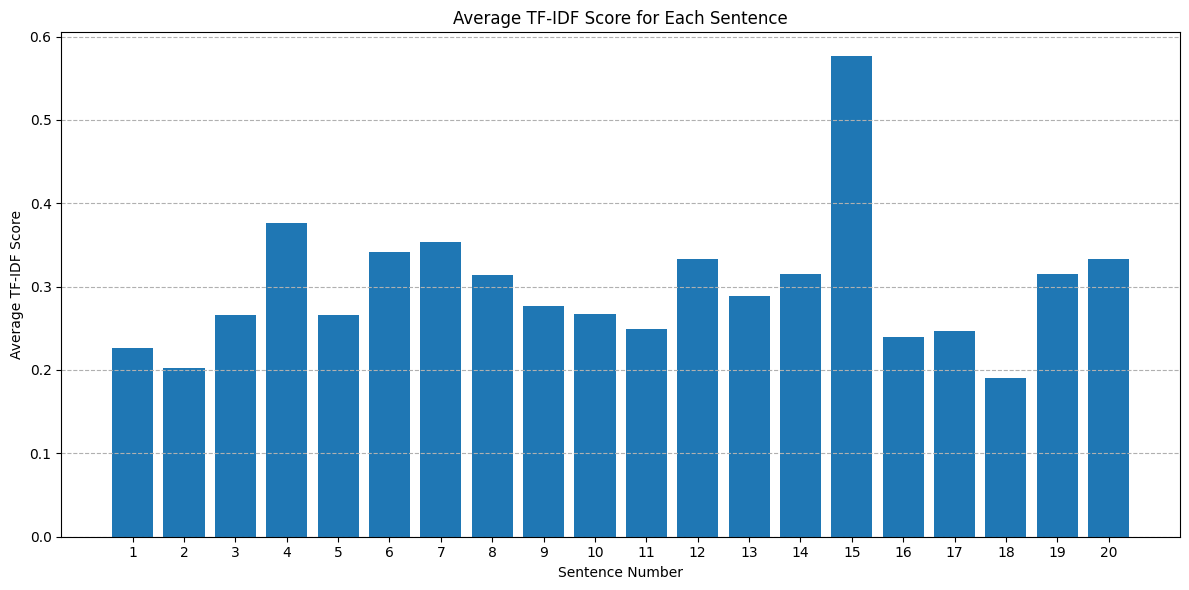


Explanation of the Histogram :
Imagine we've given each sentence in the news article a score based on the importance of the words it contains. This score is called the 'Average TF-IDF Score'.

The histogram above is like a bar chart that shows this score for each sentence:
- The horizontal line (Sentence Number):** Each number on this line represents a different sentence in the article, starting from the first sentence (1) to the last.
- The vertical bar for each sentence:** The height of each bar shows the 'Average TF-IDF Score' for that particular sentence.

 What does the height of the bar tell us?
- Taller bar: A taller bar means the sentence contains words that are considered more important and unique within the entire article. These sentences likely carry more key information.
- Shorter bar: A shorter bar means the sentence contains words that are either less important or more common throughout the article. These sentences might be supporting details or less central to the main 

In [31]:
# Visualize the average TF-IDF scores as a histogram
plt.figure(figsize=(12, 6))
plt.bar(range(1, len(sent_scores) + 1), sent_scores)
plt.xlabel("Sentence Number")
plt.ylabel("Average TF-IDF Score")
plt.title("Average TF-IDF Score for Each Sentence")
plt.xticks(range(1, len(sent_scores) + 1))
plt.grid(axis='y', linestyle='--')
plt.tight_layout()
plt.show()

# Explanation:
print("\nExplanation of the Histogram :")
print("Imagine we've given each sentence in the news article a score based on the importance of the words it contains. This score is called the 'Average TF-IDF Score'.")
print("\nThe histogram above is like a bar chart that shows this score for each sentence:")
print("- The horizontal line (Sentence Number):** Each number on this line represents a different sentence in the article, starting from the first sentence (1) to the last.")
print("- The vertical bar for each sentence:** The height of each bar shows the 'Average TF-IDF Score' for that particular sentence.")
print("\n What does the height of the bar tell us?")
print("- Taller bar: A taller bar means the sentence contains words that are considered more important and unique within the entire article. These sentences likely carry more key information.")
print("- Shorter bar: A shorter bar means the sentence contains words that are either less important or more common throughout the article. These sentences might be supporting details or less central to the main topic.")
print("\nSo, by looking at this chart, you can quickly get a sense of which sentences in the article are likely to be the most informative based on the words they use.")

# **(7) Generated Summary**
This step filters sentences based on whether their average TF-IDF score meets or exceeds the calculated threshold, compiling them into the final summary of the document.

In [33]:
# Final summary initialization
final_summ = ""

# Get summary sentences
print("\nSummary Sentences (above or equal to the threshold):")
for index, data in enumerate(sent_scores):
    if data >= threshold:
        final_summ = final_summ + " " + sentence[index]
        print(f"- {sentence[index]}")

print("\nFinal Summary:")
print(final_summ.strip())


Summary Sentences (above or equal to the threshold):
- “We’ve shown over the past 12 months we are the best team in the world.
- “To win these five trophies – for me, the five biggest prizes available to us – is incredible.
- I am so proud to have been a part of this and I can honestly say it’s an honour to play alongside these players.
- I couldn’t ask for better teammates.”

It took just 40 seconds for Manchester City to take the lead.
- Foden then got on the scoresheet himself in the 72nd minute after a prodding home from close range.
- City’s defence was largely untested for during the game, underlining the team’s dominance during this unforgettable year.
- “As a manager it is what I am most proud of; that we are always there.
- The champion heads back to England where it faces a tough title defence in the Premier League.
- It currently sits fourth in the table and will face Everton in its next fixture on Wednesday.

Final Summary:
“We’ve shown over the past 12 months we are the b